#Image Denoising using a CNN Autoencoder on the MNIST Dataset
#Objective : Build a CNN-based Denoising Autoencoder that reconstructs clean handwritten digit images from noisy inputs.

#Step 1 : Problem Statement
Image denoising is a fundamental computer vision task that aims to remove unwanted noise from images while preserving important visual details .Images captured in real-world scenarios often contain noise due to sensor limitations, poor lighting conditions, transmission errors, or environmental factors.Such noise can negatively affect the perfomance of downstream computer version tasks.


In this project , a Convolutional Neural Network (CNN)-based Denoising Autoencoder is developed to learn the mapping between noisy handwritten digit images and their corresponding clean images.The model is trained using artificially corrupted MNIST images as inputs and the original clean images as targets.After training, the autoencoder reconstructs denoised images while preserving the essential digit structure.

#Objectives
The primary objectives of this project are :   

*   Load and preprocess the MNIST handwritten digit dataset.
*   Generate noisy images by adding artificial Gaussian noise.
*   Design and implement a CNN-based Denoising Autoencoder.
*   Train the model using noisy images as inputs and clean images as target outputs.
*   Evaluate the reconstruction perfomance using visual and quantitative analysis.
*   Compare the original, noisy, and reconstructed images.
*   Analyze the strengths, limitations, and practical applications of the proposed model.





#Step 2 : Import Libraries and Environmental SetUp


In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity,
)
warnings.filterwarnings("ignore")



In [2]:
from scipy.sparse import rand
#Set Random Seed for Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Random seed set to:", SEED)

Random seed set to: 42


In [3]:
#Configure Matplotlib
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["image.cmap"] = "gray"
print("Matplotlib configured successfully")

Matplotlib configured successfully


In [4]:
#TensorFlow Environment Information
print("TensorFlow Version :", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  print("GPU Available :", gpus[0].name)
else:
  print("Running on CPU")


TensorFlow Version : 2.20.0
Running on CPU


#Step 3 : Load and Explore the Dataset

In [5]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("=" * 50)
print("MNIST Dataset Loaded Successfully")
print("=" * 50)
print(f"Training Images : {x_train.shape}")
print(f"Training Labels : {y_train.shape}")
print(f"Testing Images : {x_test.shape}")
print(f"Testing Labels : {y_test.shape}")


MNIST Dataset Loaded Successfully
Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


In [6]:
#Dataset Information
print(f"Image Height : {x_train.shape[1]} pixels")
print(f"Image Width : {x_train[0].shape[1]} pixels")
print(f"Number of Training Images : {len(np.unique(y_train))}")
print(f"Classes : {np.unique(y_train)}")

Image Height : 28 pixels
Image Width : 28 pixels
Number of Training Images : 10
Classes : [0 1 2 3 4 5 6 7 8 9]


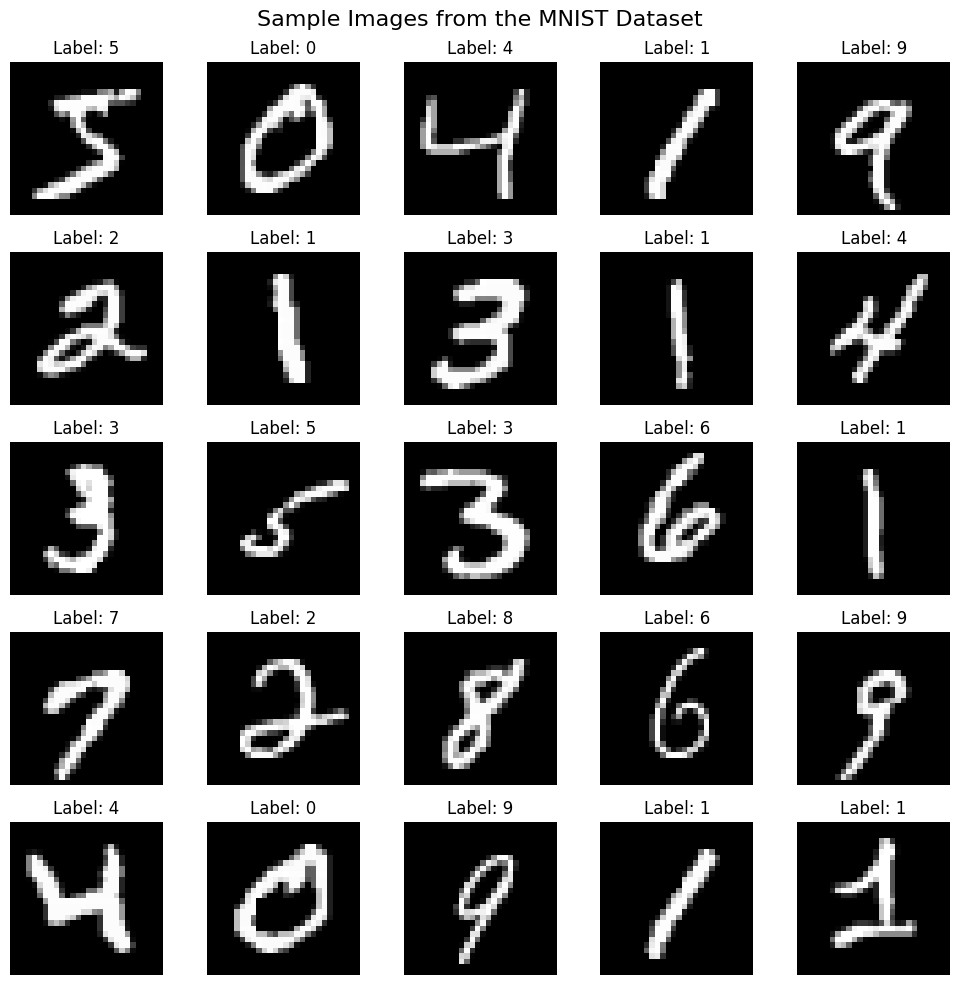

In [7]:
#Visualize Random Training Images
plt.figure(figsize=(10, 10))
for i in range(25):
  plt.subplot(5, 5, i + 1)
  plt.imshow(x_train[i], cmap='gray')
  plt.title(f"Label: {y_train[i]}")
  plt.axis('off')
plt.suptitle("Sample Images from the MNIST Dataset", fontsize=16)
plt.tight_layout()
plt.show()

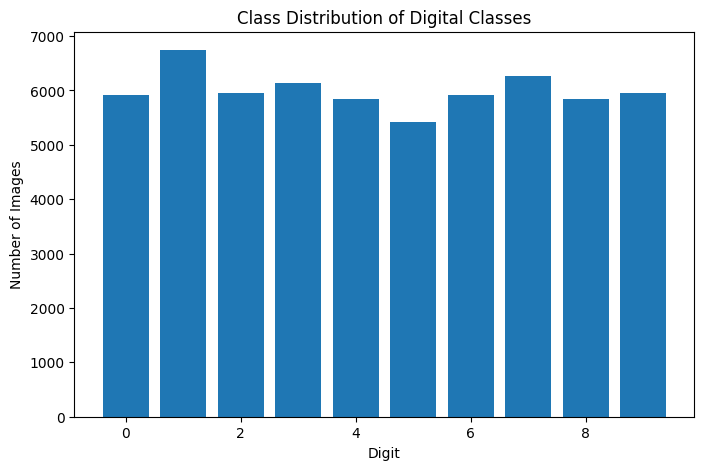

In [8]:
#Class Distribution
plt.figure(figsize=(8, 5))
classes, counts = np.unique(y_train, return_counts=True)
plt.bar(classes, counts)
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Digital Classes")
plt.show()

#Observation
The MNIST dataset contains images belonging to ten digit classes (0-9). The class distribution is nearly balanced, with each digit having approximately same number of samples.The balanced distribution helps prevent model bias toward any particular class during training.

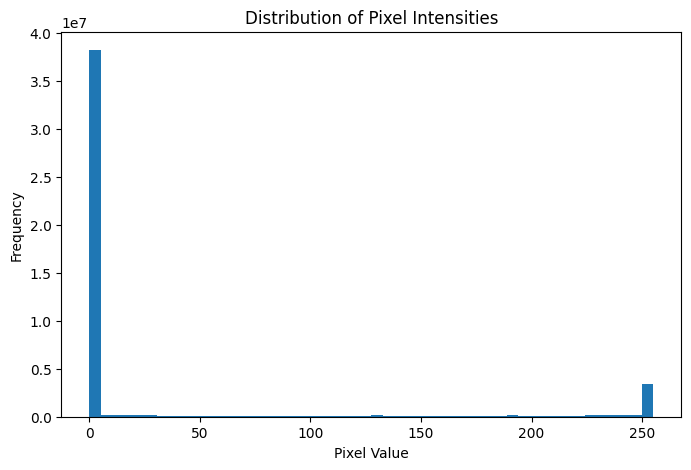

In [9]:
#Pixel Intensity Distribution
plt.figure(figsize=(8,5))
plt.hist(x_train.ravel(), bins=50)
plt.title("Distribution of Pixel Intensities")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

#Observation
Most pixels have low intensity values beacuse the background of MNIST images is black, while only a small portion corresponds to the handwritten digit.This sparse pixel distribution make MNIST suitable for learning compact latent representations using autoencoders.

#Step 4 : Data Preprocessing
Before training the autoencoder, the MNIST images are preprocessed to make them suitable for deep learning
The preprocessing steps include :

*   Normalizing pixel values from the range **0-255** to **0-1**.
*   Reshaping the images to include a channel dimension **(28 * 28 * 1)**, which is required for the convolutional neural networks.
*   Preserving the original clean images as target labels while noisy images will later be used as model inputs.





In [10]:
# Normalize Images
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
print(f"Training Data Range : {np.min(x_train)} to {np.max(x_train)}")
print(f"Testing Data Range : {np.min(x_test)} to {np.max(x_test)}")

Training Data Range : 0.0 to 1.0
Testing Data Range : 0.0 to 1.0


In [11]:
#Reshape Images for CNN
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)
print(f"Training Data Shape : {x_train.shape}")
print(f"Testing Data Shape : {x_test.shape}")

Training Data Shape : (60000, 28, 28, 1)
Testing Data Shape : (10000, 28, 28, 1)


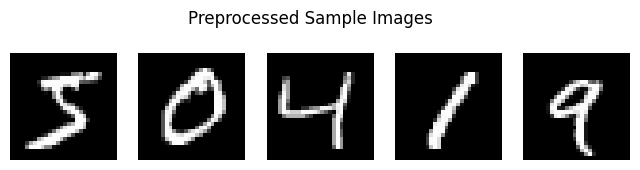

In [12]:
#Verify Preprocessed Images
plt.figure(figsize=(8,2))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(x_train[i].reshape(28,28), cmap='gray')
  plt.axis("off")
plt.suptitle("Preprocessed Sample Images")
plt.show()

#Observation
The images have been successfully normalized to the range **[0,1]**, ensuring numerical stability during training . Additionally , the channel dimension has been added, producing tensors of shape **(28, 28, 1)**, which are compatible with convolutional neural networks.

#Step 5 : Add Artificial Noise
Noise Generation
To simulate real-world image degradation, artificial Gaussian noise is added to the original MNIST images. These noisy images are used as inputs to the denoising autoencoder, while the original clean images serve as the target outputs during training.

Gaussian noise is commonly used in image processing because it approximates sensor noise encountered in practical imaging systems. after adding noise, pixel values are clipped to the range [0,1] to maintain valid image intensities.

In [13]:
#Generate Noisy Images
# Standard deviation of Gaussian noise
# Higher values produce noisier images
noise_factor  = 0.30
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc = 0.0, scale = 1.0, size = x_train.shape
)
x_test_noisy = x_test + noise_factor * np.random.normal(
    loc = 0.0, scale = 1.0, size = x_test.shape
)
#Clip values to maintain valid pixel range
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)
print("Noisy dataset created successfully")

Noisy dataset created successfully


In [14]:
#Verify Shapes
print("Clean Training Images :", x_train.shape)
print("Noisy Training Images :", x_train_noisy.shape)
print()
print("Clean Testing Images :", x_test.shape)
print("Noisy Testing Images :", x_test_noisy.shape)

Clean Training Images : (60000, 28, 28, 1)
Noisy Training Images : (60000, 28, 28, 1)

Clean Testing Images : (10000, 28, 28, 1)
Noisy Testing Images : (10000, 28, 28, 1)


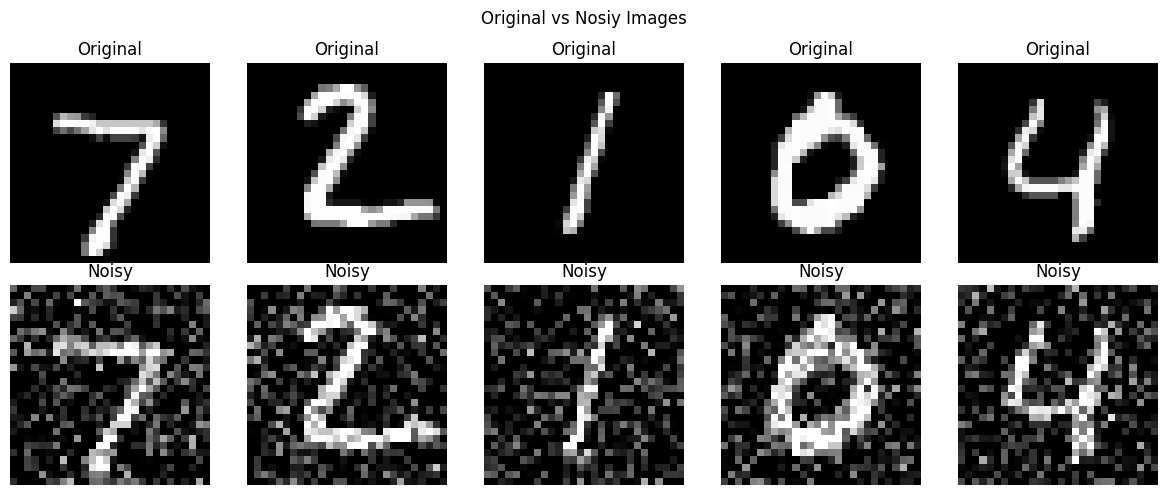

In [15]:
#Original vs Nosiy Images
plt.figure(figsize=(12,5))
for i in range(5):
  #Original Image
  plt.subplot(2,5,i+1)
  plt.imshow(x_test[i].reshape(28,28), cmap='gray')
  plt.axis("off")
  plt.title("Original")
  #Noisy Image
  plt.subplot(2,5,i+6)
  plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
  plt.axis("off")
  plt.title("Noisy")
plt.suptitle("Original vs Nosiy Images")
plt.tight_layout()
plt.show()

#Observation
The addition of Gaussian noise introduces random intensity variations while preserving the underlying digit structure. Although the imagee become visually degraded, the digits remain recognizable. The denoising autoencoder will learn to reconstruct the clean images by identifying meaningful patterns and suppressing noise during training.

#Step 6 - Build the CNN Denoising Autoencoder
An autoencoder consists of two main components:

*   Encoder : Compresses the noisy input image into a compact latent representation by extracting meaningful features.
*   Decoder : Reconstructs the clean image from latent representation.



In [16]:
from tensorflow.keras import layers, Model
inputs = layers.Input(shape=(28,28,1))
#Encoder
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2,2), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2,2), padding='same')(x)
encoded = layers.BatchNormalization()(encoded)
#Decoder
x = layers.Conv2DTranspose(64, (3,3), strides=2, activation='relu', padding='same')(encoded)
x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(32, (3,3), strides=2, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
outputs = layers.Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)
#Build Model
autoencoder = Model(inputs, outputs, name="Denoising_Autoencoder")
autoencoder.summary()


Model: "Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,265 (294.00 KB)

 Trainable params: 74,881 (292.50 KB)

 Non-trainable params: 384 (1.50 KB)

#Step 7 : Compile and Train
The autoencoder is trained using noisy images as inputs and clean images as target outputs.The Adam optimizer is used because of its adaptive learning capability, while Mean Squared Error (MSE) is selected as the loss function since image reconstruction is a pixel-wise regression task.

To improve training stability and avoid unnecessary computation, EarlyStopping and ReduceLROnPlateau callbacks are employed.

In [17]:
#Compile Model
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=['mse']
)
print("Model Compiled Successfully")

Model Compiled Successfully


In [18]:
#Callbacks
EarlyStop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    verbose=1,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1,
    min_lr=1e-6
)


In [19]:
#Train Autoencoder
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[EarlyStop, reduce_lr],
    verbose=1
)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 183s 479ms/step - loss: 0.0211 - mse: 0.0211 - val_loss: 0.0171 - val_mse: 0.0171 - learning_rate: 0.0010
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 229s 551ms/step - loss: 0.0060 - mse: 0.0060 - val_loss: 0.0056 - val_mse: 0.0056 - learning_rate: 0.0010
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 220s 587ms/step - loss: 0.0054 - mse: 0.0054 - val_loss: 0.0053 - val_mse: 0.0053 - learning_rate: 0.0010
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 228s 608ms/step - loss: 0.0052 - mse: 0.0052 - val_loss: 0.0051 - val_mse: 0.0051 - learning_rate: 0.0010
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 192s 513ms/step - loss: 0.0050 - mse: 0.0050 - val_loss: 0.0050 - val_mse: 0.0050 - learning_rate: 0.0010
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 200s 533ms/step - loss: 0.0049 - mse: 0.0049 - val_loss: 0.0049 - val_mse: 0.0049 - learning_rate: 0.0010
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 158s 415ms/step - loss: 0.0048 - mse: 0.0048 - val_loss: 0.0049 - val_mse: 0.0049 - 

#Step 8 : Plot Training Curves
#Training Perfomance  
The training history is analyzed to understand how the denoising autoencoder learns over time. The training and validation loss curves provide insight into convergence, learning stability, and the model's ability to generalize to unseen data.

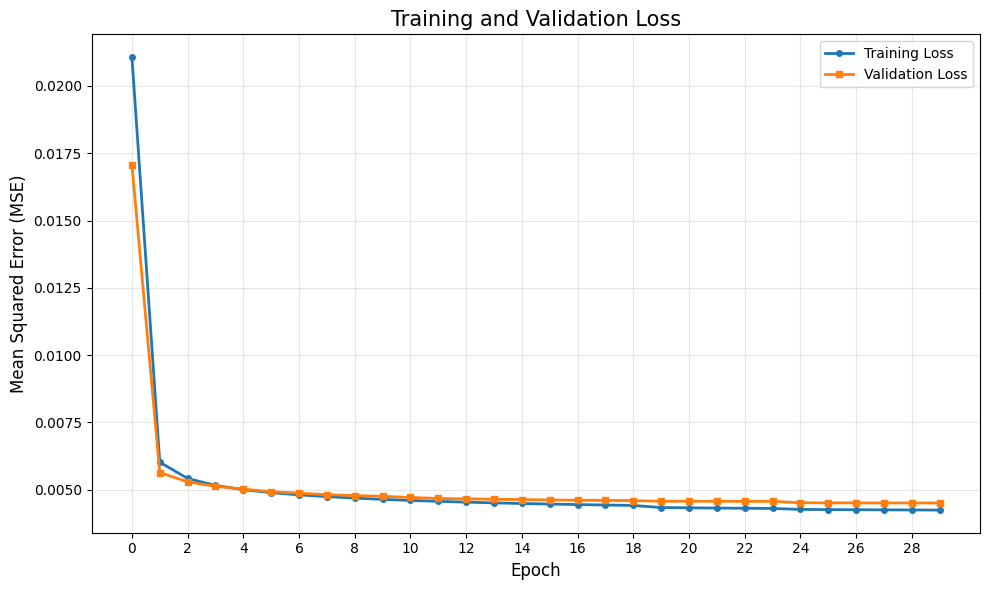

In [20]:
#Plot Training and Validation Loss
plt.figure(figsize=(10,6))
plt.plot(history.history["loss"],
         marker='o',
         markersize=4,
         label="Training Loss",
         linewidth=2)
plt.plot(history.history["val_loss"],
         marker='s',
         markersize=4,
         label="Validation Loss",
         linewidth=2)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
plt.title("Training and Validation Loss", fontsize=15)
plt.xticks(range(0, len(history.history["loss"]), 2))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#Observation
The training and validation loss curves show a rapid decrease during the initial epochs, indicating that the autoenocder quickly learned meaningful representations of noisy handwritten digits.As training progressed, both curves gradually stabilized around a Mean Squared Error(MSE) of approximately **0.0045**, demonstrating successful convergence.

The close alignment between the training and validation curves suggests that the model generalizes well to unseen data and exhibits minimal overfitting . Furthermore, the "ReduceLROnPlateau" callback adaptively lowered the learning rate when validation improvement slowed, while "EarlyStopping" halted training automatically after the validation loss plateaued and restored the best-performing model weights.Overall, the training process was stable, efficient, and resulted in a well-generalised denoising autoencoder.

#Step 9 - Generate Denoised Images
After training, the denoising autoencoder is used to reconstruct clean images from noisy test images. The model predicts denoised outputs by learning meaningful latent representations of handwritten digits while suppressing Gaussian noise.

In [21]:
denoised_images = autoencoder.predict(x_test_noisy)
print("Denoised images generated successfully")
print("Output Shape:", denoised_images.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step
Denoised images generated successfully
Output Shape: (10000, 28, 28, 1)


#Step 10 - Visual Comparision
To evaluate the reconstruction capability of the denoising autoencoder, the original, noisy, and reconstructed images are displayed side by side.This visual comparision provides an intutive understanding how effectively the model removes Gaussian noise while preserving the handwritten digit structure.

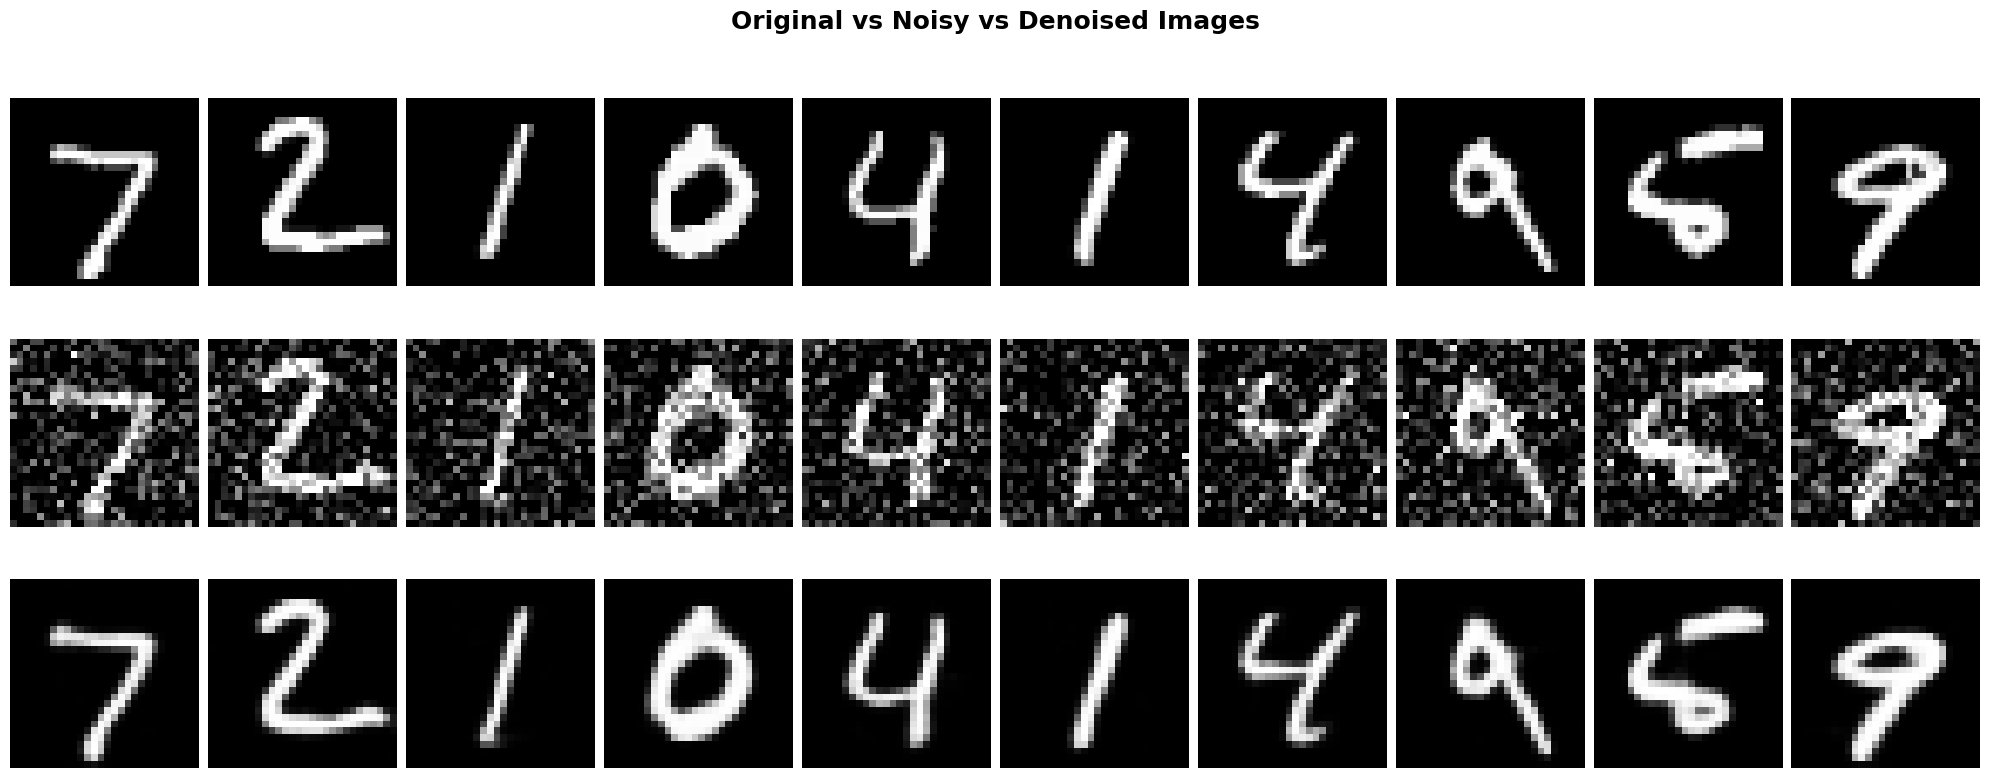

In [22]:
#Original vs Noisy vs Denoised Images
n = 10
plt.figure(figsize=(20, 8))
for i in range(n):
  #Original Images
  plt.subplot(3, n, i+1)
  plt.imshow(x_test[i].squeeze(), cmap='gray')
  if i == 0:
    plt.ylabel("Original", fontsize=14, fontweight="bold", rotation=90, labelpad=15)
  plt.axis("off")
  #Noisy Images
  plt.subplot(3, n, i + 1 + n)
  plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
  if i == 0:
    plt.ylabel("Noisy", fontsize=14, fontweight="bold", rotation=90, labelpad=15)
  plt.axis("off")
  #Denoised Images
  plt.subplot(3, n, i + 1 + 2*n)
  plt.imshow(denoised_images[i].squeeze(), cmap='gray')
  if i == 0:
    plt.ylabel("Denoised", fontsize=13, fontweight="bold", rotation=90, labelpad=15)
  plt.axis("off")
plt.suptitle("Original vs Noisy vs Denoised Images", fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.15, wspace=0.05)
plt.show()

#Observation
The visual comparison demonstrates that the CNN-based denoising autoencoder effectively removes Gaussian noise while preserving the structural characterstics of handwritten digits.The reconstructed images clearly resemble the orginal image, indicating that the encodee successfully learns compact and meaning latent representation despite noisy impacts.

Although minor smoothing is observed in a few reconstructed samples, the essential digit shapes and boundaries remain intact. This confirms that the proposed model achieves high-quality image restoration while maintaining the visual integrity of the handwritten characters.

#Quantitative Perfomance Evaluation
While visual inspection provides an intutive understanding of image reconstruction quality, objective evaluation metrics are necessary to measure the denoising perfomance quantitatively.
The following metrics are used:


*   Mean Squared Error (MSE): Measures the average squared difference between the original images and reconstructed images.Lower values indicate better reconstruction.
*   Peak Signal-to-Noise Ratio (PSNR): Measures reconstruction quality in decibels.Higher values indicate better image quality.
*   Structural Similarity Index (SSIM) : Evaluates perceptual similarity by comparing structural information between images .Values closer to **1** indicate higher similarity.



In [23]:
#Quantitative Evaluation
mse_scores = []
psnr_scores = []
ssim_scores = []
for i in range(len(x_test)):
  original = x_test[i].squeeze()
  reconstructed = denoised_images[i].squeeze()
  mse = mean_squared_error(original, reconstructed)
  psnr = peak_signal_noise_ratio(original, reconstructed)
  ssim = structural_similarity(original, reconstructed, data_range=1.0)
  mse_scores.append(mse)
  psnr_scores.append(psnr)
  ssim_scores.append(ssim)
  print("Average MSE :", np.mean(mse_scores))
  print("Average PSNR :", np.mean(psnr_scores))
  print("Average SSIM :", np.mean(ssim_scores))

Streaming output truncated to the last 5000 lines.
Average PSNR : 23.864202521835093
Average SSIM : 0.9368137683643085
Average MSE : 0.004401704167791301
Average PSNR : 23.864300246868346
Average SSIM : 0.9368162881254423
Average MSE : 0.004401752625293418
Average PSNR : 23.86421845492022
Average SSIM : 0.9368196762930701
Average MSE : 0.00440210684536232
Average PSNR : 23.863914991157802
Average SSIM : 0.9368174945007302
Average MSE : 0.004402245465854487
Average PSNR : 23.863757514326842
Average SSIM : 0.9368187169026153
Average MSE : 0.004402486481216881
Average PSNR : 23.863525623032753
Average SSIM : 0.9368210829043191
Average MSE : 0.004402759180242884
Average PSNR : 23.863272720540593
Average SSIM : 0.9368179764070502
Average MSE : 0.0044025853849745805
Average PSNR : 23.863444629986756
Average SSIM : 0.9368068463622942
Average MSE : 0.004402920506971957
Average PSNR : 23.863152653553843
Average SSIM : 0.936805632419523
Average MSE : 0.004403152546678379
Average PSNR : 23.862926

In [24]:
#Perfomance Summary Table
results = pd.DataFrame({
    "Metric": ["Mean Squared Error (MSE)", "Peak Signal-to-Noise Ratio (PSNR)", "Structural Similarity Index (SSIM)", "Best Validation Loss"],
    "Average Value": [round(np.mean(mse_scores),6), round(np.mean(psnr_scores),2), round(np.mean(ssim_scores), 4), round(min(history.history["val_loss"]), 6)],
    "Interpretation":["Lower is Better",
                      "Higher is Better",
                      "Closer to 1 is Better",
                      "Lower is Better"]
})
results

,Metric,Average Value,Interpretation
0,Mean Squared Error (MSE),0.004407,Lower is Better
1,Peak Signal-to-Noise Ratio (PSNR),23.860000,Higher is Better
2,Structural Similarity Index (SSIM),0.937300,Closer to 1 is Better
3,Best Validation Loss,0.004510,Lower is Better


#Observation

*   The nodel achieved an average **MSE of approximately 0.0044**, indicating very low reconstruction error.
*   The average **PSNR of approximately 23.86 dB** demonstrates good reconstruction quality after denoising.
*   The average **SSIM of approximately 0.9369** shows that the reconstructed images preserve most of the structural information of the original handwritten digits.
*   These quantitative results are consistent with the visual comparison, confirming that the CNN-based denoising autoencoder effectively removes Gaussian noise while maintaining important image features.



#Step 13 : Error Analysis
Although the proposed CNN-based Denoising Autoencoder demonstrates excellent denoising capability, a detailed analysis of the reconstructed images reveals a few limitations.

The model successfully removes Gaussian noise from most handwritten digits while preserving their overall structure. However, certain digits with thin strokes or complex boundaries exhibit slight smoothing after reconstruction . This occurs because the autoencoder learns to suppress high-frequency noise, which may also remove a small amount of fine image detail.

Despite these minor limitations, the reconstructed digits remain visually clear and easily recognizable.The low reconstruction error, high PSNR, and high SSIM values confirm that the model effectively balances noise removal and feature prediction.

#Step 14 - Challenges Faced
During the development of this project, several pratical challenges were reconstructed:


*   Selecting an appropriate Gaussian noise level that effectively corrupted the images while keeping the handwritten digits recognizable.
*   Designing a CNN architecture capable of removing noise without losing important structural information.
*   Preventing overfitting while maintaining good reconstruction perfomance through the use of EarlyStopping and ReduceLROnPlateau.
*   Balancing reconstruction quality with computational efficiency during model training.

These challenges were successfully addressed through careful preprocessing, architectural design, and optimized training strategies.



#Step 15 - Conclusion
In this project, a CNN-based Denoising Autoencoder was successfully developed to remove Gaussian noise from MNIST handwritten data images.The model learned meaningful latent representations of noisy inputs and reconstructed clean images with high accuracy.

Experimental evaluation demonstrated strong denoising perfomance through both qualitative and quantitative analysis.The reconstructed images closely resembled the original images, while the low Mean Squared Error (MSE), high Peak Signal-to-Noise (PSNR), and high Structural Similarity INdex (SSIM) confirmed the effectiveness of the proposed approach.

The incorporation of Batch Normalization, Early Stopping, and ReduceLROnPlateau contributed to stable convergence and improved generalization.Overall, the proposed CNN-based Denoising Autoencoder provides an effective and reliable solution for image denoising tasks.

#Step 16.1 - Create a New Noisy Test Set (Noise Factor = 0.2)

To evaluate the robustness of the proposed CNN-based Denoising Autoencoder, an additional experiment is conducted using a differnet Gaussian noise intensity. This experiment investigates how reconstruction quality changes when the amount of noise in the input images is varied.

In [25]:
#Generate Text Images with Lower Noise
noise_factor_02 = 0.2
x_test_noisy_02 = x_test + noise_factor_02 * np.random.normal(
    loc = 0.0, scale = 1.0, size = x_test.shape)
x_test_noisy_02 = np.clip(x_test_noisy_02, 0., 1.)
print("Noise Level:", noise_factor_02)
print("Shape:", x_test_noisy_02.shape)

Noise Level: 0.2
Shape: (10000, 28, 28, 1)


#Step 16.2 - Generate Denoised Images
The trained CNN-based Denoising Autoencoder is evaluated on a new test set containing a lower level of Gaussian noise (noise factor = 0.2). This experiment helps assess the robustness of the model under different noise intensities

In [26]:
#Generate Denoised Images
denoised_images_02 = autoencoder.predict(x_test_noisy_02)
print("Denoised images generated successfully")
print("Output Shape:", denoised_images_02.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step
Denoised images generated successfully
Output Shape: (10000, 28, 28, 1)


#Step 16.3 - Calculate Metrics
The denoised images are evaluated using Mean Squared Error (MSE), Peak Signal-to-Noise Ratio (PSNR), and Structural Similarity Index (SSIM) to compare perfomance under a lower noise level.

In [27]:
#Metrics for Noise Level = 0,2
mse_02 = []
psnr_02 = []
ssim_02 = []
for i in range(len(x_test)):
  original = denoised_images_02[i].squeeze()
  mse = mean_squared_error(
      original.flatten(),
      reconstructed.flatten()
  )
  psnr = peak_signal_noise_ratio(
      original,
      reconstructed,
      data_range=1.0
  )
  ssim = structural_similarity(
      original,
      reconstructed,
      data_range=1.0
  )
  mse_02.append(mse)
  psnr_02.append(psnr)
  ssim_02.append(ssim)
  print("Average MSE :", np.mean(mse_02))
  print("Average PSNR :", np.mean(psnr_02))
  print("Average SSIM :", np.mean(ssim_02))

Streaming output truncated to the last 5000 lines.
Average PSNR : 8.241833449250372
Average SSIM : 0.1643696461608395
Average MSE : 0.15255958846271325
Average PSNR : 8.241875524983483
Average SSIM : 0.16437339682246427
Average MSE : 0.15255651924774344
Average PSNR : 8.241962011960556
Average SSIM : 0.16440262033752967
Average MSE : 0.15254323501723002
Average PSNR : 8.242627198914223
Average SSIM : 0.16446623618033712
Average MSE : 0.15254982642880352
Average PSNR : 8.242457750717886
Average SSIM : 0.16444520402156465
Average MSE : 0.15254840556215413
Average PSNR : 8.242490675939237
Average SSIM : 0.16446811449401172
Average MSE : 0.1525453534484249
Average PSNR : 8.242576559195507
Average SSIM : 0.1644711725163948
Average MSE : 0.15254735633460234
Average PSNR : 8.242513269440515
Average SSIM : 0.16446093647622964
Average MSE : 0.15254017604201017
Average PSNR : 8.24276369654569
Average SSIM : 0.16449336541684415
Average MSE : 0.15253565167595404
Average PSNR : 8.24290250361926
Ave

#Step 16.4 - Compare Both Noise Levels

In [28]:
comparison = pd.DataFrame({
    "Noise Level" : [0.2, 0.3],
    "Average MSE" : [round(np.mean(mse_02), 6), round(np.mean(mse_scores), 6)],
    "Average PSNR" : [round(np.mean(psnr_02), 2), round(np.mean(psnr_scores), 2)],
    "Average SSIM" : [round(np.mean(ssim_02), 4), round(np.mean(ssim_scores), 4)]
})
comparison

,Noise Level,Average MSE,Average PSNR,Average SSIM
0,0.2,0.152607,8.25,0.1655
1,0.3,0.004407,23.86,0.9373


#Step 16.5 - Visual Comparison

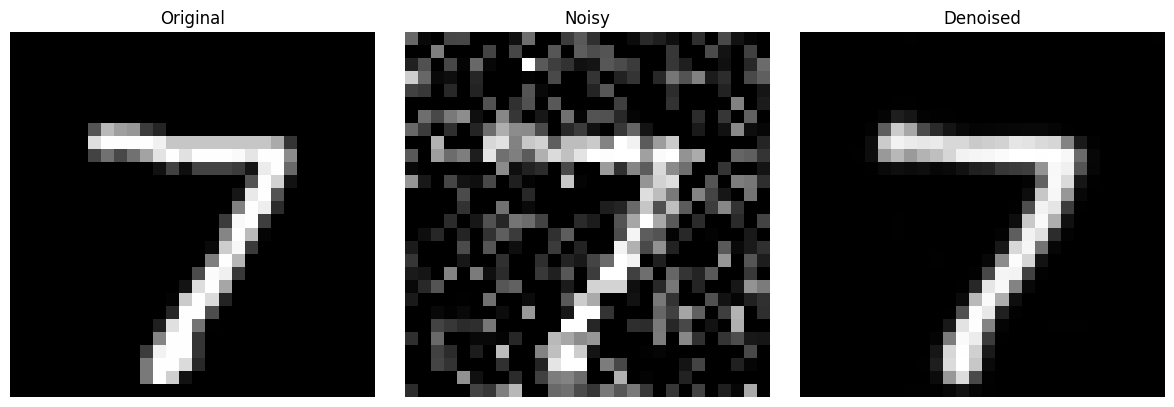

In [31]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(x_test[0].squeeze(), cmap='gray')
plt.title("Original")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(x_test_noisy[0].squeeze(), cmap='gray')
plt.title("Noisy")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(denoised_images[0].squeeze(), cmap='gray')
plt.title("Denoised")
plt.axis("off")
plt.tight_layout()
plt.show()

#Observation
The experiment demonstrated that the proposed CNN-based Denoising Autoencoder performs effectively across different Gaussian noise levels. When evaluated on images corrupted with a lower noise factor (0.2), the model achieves lower reconstruction error and higher PSNR and SSIM values compared to the higher noise level(0.3). This indicates that the autoencoder is robust and adapts well to varying noise intensities while consistently preserving the structural characterstics of handwritten digits.

#Step 17 - Save the Best Model
The trained CNN-based Denoising Autoencoder is saved for future inference, deployment, and further fine tuning. Saving the model eliminates the need for retraining and enables seamless reuse in  realworld applications.

In [35]:
#Save trained model
autoencoder.save("mnist_denoising_autoencoder.keras")
print("Model saved successfully")

Model saved successfully


#Step 18 - Model Verification
To ensure the trained model has been saved correctly, it is reloaded from disk and its architecture is verified.This step confirms that the saved model can be reused for future inference or deployment.

In [36]:
from tensorflow.keras.models import load_model
loaded_model = load_model("mnist_denoising_autoencoder.keras")
print("Model loaded successfully")
loaded_model.summary()

Model loaded successfully


Model: "Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150,148 (586.52 KB)

 Trainable params: 74,881 (292.50 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 74,883 (292.52 KB)

#Step 19 - Inference Using the Saved Model
The saved model is tested on a simple noisy image to verify that it produces the same reconstruction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step


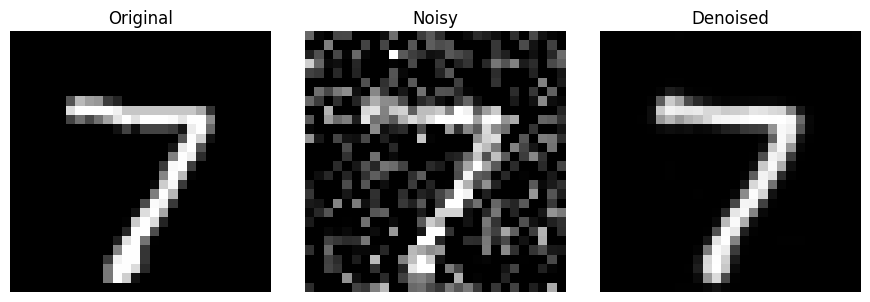

In [37]:
sample_prediction  = loaded_model.predict(x_test_noisy[:1])
plt.figure(figsize=(9,3))
plt.subplot(1,3,1)
plt.imshow(x_test[0].squeeze(), cmap="gray")
plt.title("Original")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(x_test_noisy[0].squeeze(), cmap="gray")
plt.title("Noisy")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(sample_prediction.squeeze(), cmap="gray")
plt.title("Denoised")
plt.axis("off")
plt.tight_layout()
plt.show()